# $\color{orange}{\text{Chapter 12 of "Statistical Physics"}}$
# $\color{orange}{\text{12.3 Toestandsvergelijking van een ideaal Bose gas}}$

 
Author: Jan Ryckebusch (notebook version September 2022 onwards)


In [ ]:
import math as m
import matplotlib.pyplot as plt 
import numpy as np

# tweak the parameters of the plots ...
# nothing essential, makes things look nicer ...
params = {'legend.fontsize' : 20,
          'axes.linewidth'  : 2.5,
          'axes.labelsize'  : 20,
          'lines.linewidth' : 2, 
          'xtick.major.width' : 3,
          'xtick.major.size'  : 12,
          'ytick.major.width' : 3,
          'ytick.major.size'  : 12,
          'xtick.major.pad'  : 10,
          'xtick.minor.width' : 2,
          'xtick.minor.size'  : 6,
          'ytick.minor.width' : 2,
          'ytick.minor.size'  : 6,
          'xtick.labelsize'    : 18,
          'ytick.labelsize'    : 18 }
plt.rcParams.update(params)
plt.rc("font",family="serif",weight='bold') 

In [ ]:
def gfuncz(z,N,k):
#Series expansion for the g_{N}(z) function for the ideal Bose gas
# z is the fugacity (z  approaching 1: k must be large (80 or so)) 
# N = 1/2, 3/2, 5/2, 7/2, ...
#k determines the order of the series expansion
# 
  return sum([z**(L+0.0)/((L+0.0)**N) for L in range(1,k)])

In [ ]:
zval=[]         # create a list with the fugacity values
PVoverNkT=[]    # create a list for (PV)/(NkT)
CVoverNk =[]    # create a list for (C_V)/(Nk)
SoverNk  =[]    # create a list for S/(Nk)
g32z = []       # create a list for density times \lambda ^3
zoverzm1 = []   # create a list for z / (1-z)

nauw=int(100)         # the order of the series expansion (80 is fine...)
z=0.02               # lowest z value considered    

while(z<=0.995): # for a Base gas 0<=z<=1
  koe=gfuncz(z,2.5,nauw)/gfuncz(z,1.5,nauw)
  PVoverNkT.append(koe)
  koef=15./4.*gfuncz(z,2.5,nauw)/gfuncz(z,1.5,nauw) - 9./4.*gfuncz(z,1.5,nauw)/gfuncz(z,0.5,nauw) 
  CVoverNk.append(koef)
  koeg=5./2.*gfuncz(z,2.5,nauw)/gfuncz(z,1.5,nauw) - m.log(z)
  SoverNk.append(koeg)
  g32z.append(gfuncz(z,1.5,nauw))
  zval.append(z)
  zoverzm1.append(z/(1.-z)*0.01)
  z=z+0.01
# end of the numerical calculations (yes, indeed)

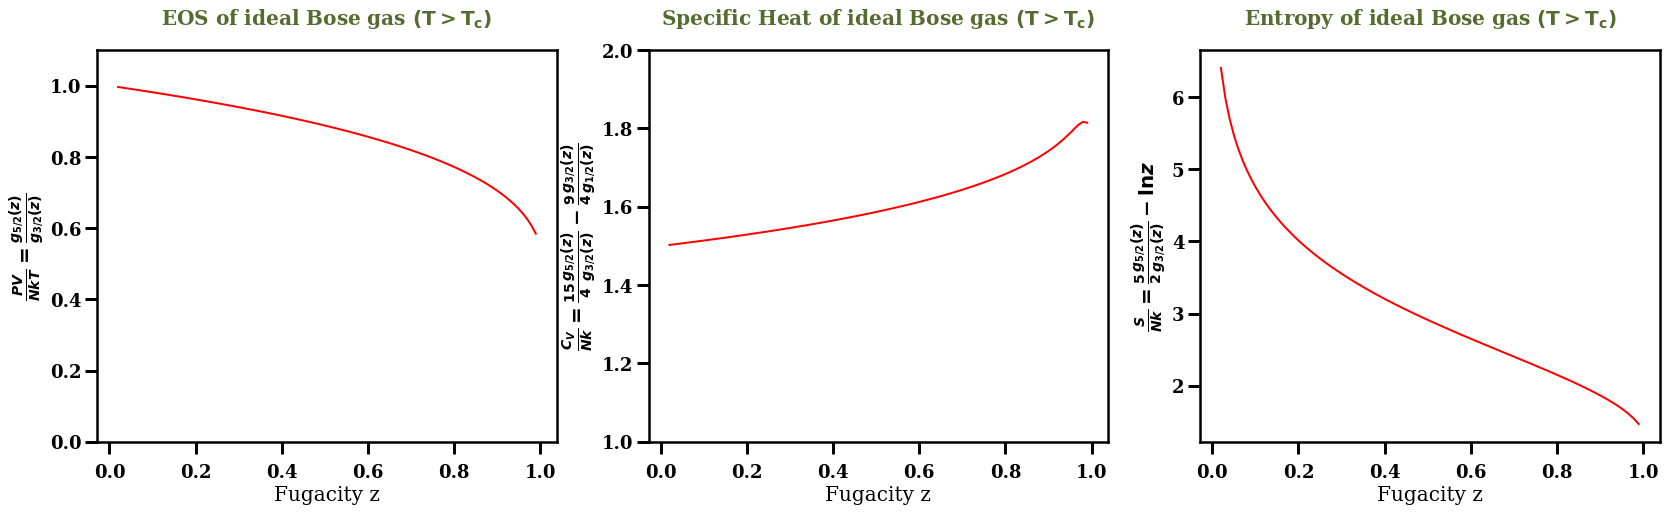

In [ ]:
figall=plt.figure(figsize=(28,8))
figall.subplots_adjust(bottom=0.2) # create room for x-axis label
figall.tight_layout()

ax1=figall.add_subplot(131) 
ax1.plot(zval, PVoverNkT, "r-", linewidth=2,label=r'EOS of ideal Bose gas')
ax1.set_xlabel(r'Fugacity z')
ax1.set_ylabel(r'$\frac{ PV} {NkT} = \frac {g_{5/2} (z) } {g_{3/2} (z) }$')
ax1.set_title(r'EOS of ideal Bose gas $\bf (T>T_{c})$',fontsize=20,y=1.05,color='darkolivegreen',weight='bold')
ax1.set_ylim([0.,1.1])

ax2=figall.add_subplot(132)
ax2.plot(zval, CVoverNk, "r-", linewidth=2, label=r'Specific Heat of Ideal Bose gas')
ax2.set_xlabel(r'Fugacity z')
ax2.set_ylabel(r'$\frac{ C_V} {Nk} = \frac {15} {4} \frac {g_{5/2} (z) } {g_{3/2} (z) } - \frac {9} {4} \frac {g_{3/2} (z) } {g_{1/2} (z) }$')
ax2.set_title(r'Specific Heat of ideal Bose gas $\bf (T>T_{c})$',fontsize=20,y=1.05,color='darkolivegreen',weight='bold')
ax2.set_ylim([1.,2.])

ax3=figall.add_subplot(133)
ax3.plot(zval, SoverNk, "r-", linewidth=2, label=r'Entropy of Ideal Bose gas')
ax3.set_xlabel(r'Fugacity z')
ax3.set_ylabel(r'$\frac{S} {Nk} = \frac {5} {2} \frac {g_{5/2} (z) } {g_{3/2} (z) } - \ln z$')
ax3.set_title(r'Entropy of ideal Bose gas $\bf (T>T_{c})$',fontsize=20,y=1.05,color='darkolivegreen',weight='bold')

figall.savefig('ThreePropertiesIdealBoseGas.eps',dpi=300)
figall.savefig('ThreePropertiesIdealBoseGas.pdf',dpi=300)

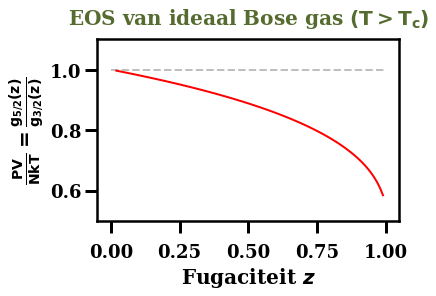

In [ ]:

# Separate figures: equation-of-state, specific heat and entropy of the Ideal Bose gas in 3D

# Figure for EOS vs fugacity
figeos=plt.figure(2)
figeos.tight_layout()
figeos.subplots_adjust(left=0.2,bottom=0.25) # create room for x-axis and y-axis label
ax1a=figeos.add_subplot(111)
ax1a.plot(zval, PVoverNkT, "r-", linewidth=2,label=r'EOS of ideal Bose gas')
ax1a.set_xlabel(r'Fugaciteit $z$',weight='bold')
ax1a.set_ylabel(r'$\bf \frac{ PV} {NkT} = \frac {g_{5/2} (z) } {g_{3/2} (z) }$',weight='bold')
ax1a.set_title(r'EOS van ideaal Bose gas $\bf (T>T_{c})$',fontsize=20,y=1.05,color='darkolivegreen',weight='bold')
ax1a.set_ylim([0.5,1.1])
ax1a.hlines(1.,0.,1,linestyles='dashed',color='grey',alpha=0.5)
figeos.savefig('EOSofIdealBoseGas.eps',dpi=600)
figeos.savefig('EOSofIdealBoseGas.pdf') 


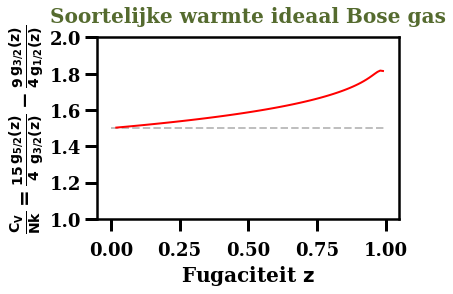

In [ ]:
# Figure for Specific heat vs fugacity
figcv=plt.figure(3)
figcv.tight_layout()
figcv.subplots_adjust(left=0.2,bottom=0.25) # create room for x-axis and y-axis label
ax2a=figcv.add_subplot(111)
ax2a.plot(zval, CVoverNk, "r-", linewidth=2, label=r'Specific Heat of Ideal Bose gas')
ax2a.hlines(1.5,0.,1,linestyles='dashed',color='grey',alpha=0.5)
ax2a.set_xlabel(r'Fugaciteit $\bf z$',weight='bold')
ax2a.set_ylabel(r'$\bf \frac{ C_V} {Nk} = \frac {15} {4} \frac {g_{5/2} (z) } {g_{3/2} (z) } - \frac {9} {4} \frac {g_{3/2} (z) } {g_{1/2} (z) }$',weight='bold')
ax2a.set_title(r'Soortelijke warmte ideaal Bose gas',fontsize=20,y=1.05,color='darkolivegreen',weight='bold')
ax2a.set_ylim([1.,2.])
figcv.savefig('CVofIdealBoseGas.eps',dpi=600)
figcv.savefig('CVofIdealBoseGas.pdf') 

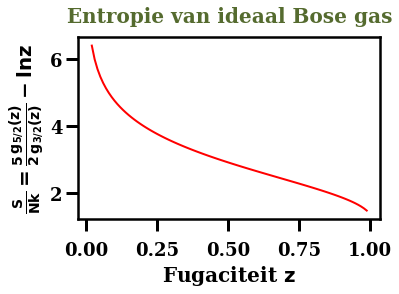

In [ ]:
# Figure for Entropy vs fugacity
figS=plt.figure(4)
figS.tight_layout()
figS.subplots_adjust(left=0.2,bottom=0.25) # create room for x-axis label
ax3a=figS.add_subplot(111)
ax3a.plot(zval, SoverNk, "r-", linewidth=2, label=r'Entropy of Ideal Bose gas')
ax3a.set_xlabel(r'Fugaciteit $\bf z$',weight='bold')
ax3a.set_ylabel(r'$\bf \frac{S} {Nk} = \frac {5} {2} \frac {g_{5/2} (z) } {g_{3/2} (z) } - \ln z$',weight='bold')
ax3a.set_title(r'Entropie van ideaal Bose gas',fontsize=20,y=1.05,color='darkolivegreen',weight='bold')
figS.savefig('SofIdealBoseGas.eps',dpi=600)
figS.savefig('SofIdealBoseGas.pdf')

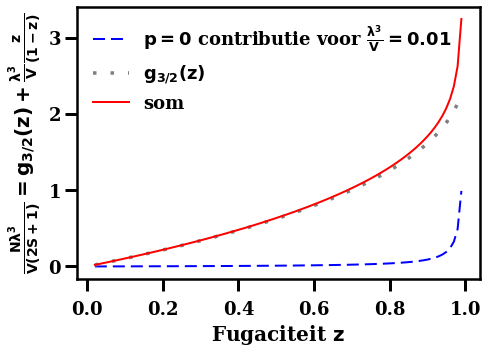

In [ ]:
# Figure for (N \lambda ^3)/(V(2S+1)) vs fugacity
figlam=plt.figure(figsize=(8,6))
figlam.tight_layout()
figlam.subplots_adjust(left=0.2,bottom=0.25) # create room for x-axis label
ax4a=figlam.add_subplot(111)
ax4a.plot(zval, zoverzm1, linewidth=2, dashes=[6,3],color='blue',label=r'$\bf p=0$ contributie voor $\bf \frac {\lambda ^3} {V}=0.01$')
ax4a.plot(zval, g32z, linewidth=3.5, dashes=[1,4],color='grey',label=r'$\bf g_{3/2}(z)$')
ax4a.plot(zval, np.array(g32z)+np.array(zoverzm1), "r-", linewidth=2, label=r'som')

ax4a.set_xlabel(r'Fugaciteit $\bf z$',weight='bold')
ax4a.set_ylabel(r'$\bf \frac{N \lambda ^3} {V (2S+1)} = g_{3/2} (z) +  \frac {\lambda ^3} {V} \frac {z} {(1-z)}$',weight='bold')
ax4a.legend(frameon=False,fontsize=18,ncol=1,loc='best')
#ax4a.set_title(r'Entropie van ideaal Bose gas $(T>T_{c})$',fontsize=20,y=1.05,color='darkolivegreen',weight='bold')
figlam.savefig('Lam3OverV.eps',dpi=1200)
figlam.savefig('Lam3OverV.pdf',dpi=600)